SALES PREDICTION USING PYTHON

Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

Load Dataset

In [2]:
df = pd.read_csv("advertising.csv")
df.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9


 Dataset Information

In [3]:
print("Dataset Shape :", df.shape)

print("\nColumns:")
print(df.columns)

print("\nDataset Info:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape : (200, 4)

Columns:
Index(['TV', 'Radio', 'Newspaper', 'Sales'], dtype='object')

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB
None

Missing Values:
TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64


Data Cleaning

Remove duplicate rows

In [4]:
df = df.drop_duplicates()

Remove unnamed column if present

In [5]:
if 'Unnamed: 0' in df.columns:
    df.drop('Unnamed: 0', axis=1, inplace=True)

print("\nDataset Shape After Cleaning :", df.shape)

print("\nMissing Values After Cleaning:")
print(df.isnull().sum())


Dataset Shape After Cleaning : (200, 4)

Missing Values After Cleaning:
TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64


Data Visualization

In [6]:
sns.set_style("whitegrid")

Sales Distribution

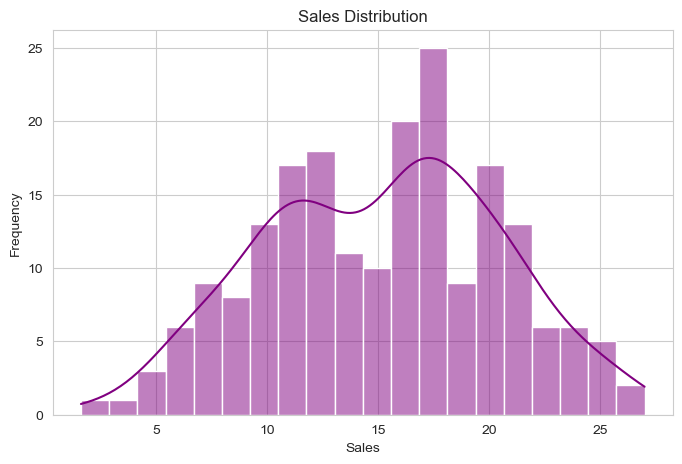

In [7]:
plt.figure(figsize=(8,5))

sns.histplot(df['Sales'], bins=20,
             kde=True,
             color='purple')

plt.title("Sales Distribution")
plt.xlabel("Sales")
plt.ylabel("Frequency")

plt.show()

Advertising vs Sales

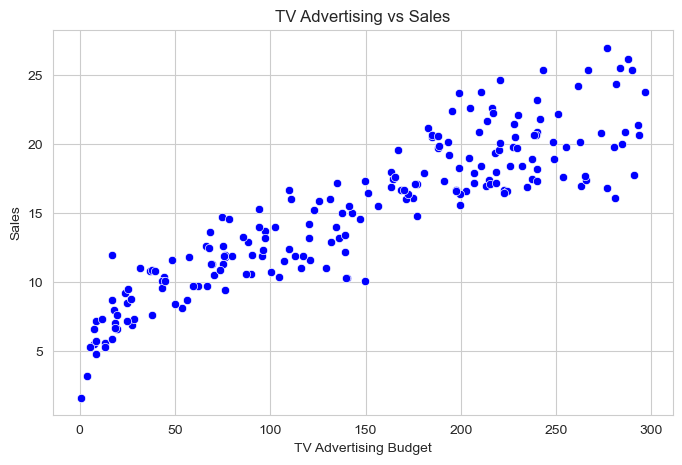

In [8]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='TV',
    y='Sales',
    data=df,
    color='blue'
)

plt.title("TV Advertising vs Sales")
plt.xlabel("TV Advertising Budget")
plt.ylabel("Sales")

plt.show()

Correlation Heatmap

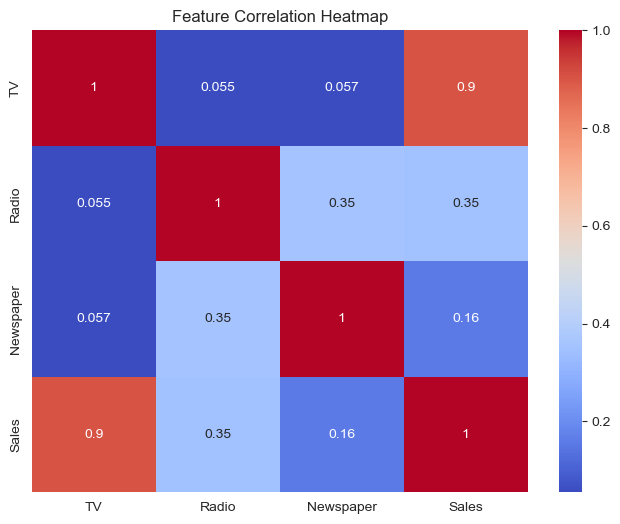

In [9]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Feature Correlation Heatmap")

plt.show()

Features and Target

In [10]:
X = df[['TV', 'Radio', 'Newspaper']]
y = df['Sales']

 Train Test Split

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("\nTraining Shape :", X_train.shape)
print("Testing Shape :", X_test.shape)


Training Shape : (160, 3)
Testing Shape : (40, 3)


Model Training

In [12]:
model = LinearRegression()

model.fit(X_train, y_train)

print("\nModel Training Completed!")


Model Training Completed!


Prediction

In [13]:
y_pred = model.predict(X_test)

print("\nSample Predictions:")
print(y_pred[:10])


Sample Predictions:
[17.0347724  20.40974033 23.72398873  9.27278518 21.68271879 12.56940161
 21.08119452  8.69035045 17.23701254 16.66657475]


Model Evaluation

In [14]:
mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("\nModel Evaluation")

print("Mean Absolute Error :", mae)
print("Mean Squared Error :", mse)
print("Root Mean Squared Error :", rmse)
print("R2 Score :", r2)


Model Evaluation
Mean Absolute Error : 1.274826210954934
Mean Squared Error : 2.9077569102710905
Root Mean Squared Error : 1.7052146229349228
R2 Score : 0.9059011844150826


Actual vs Predicted

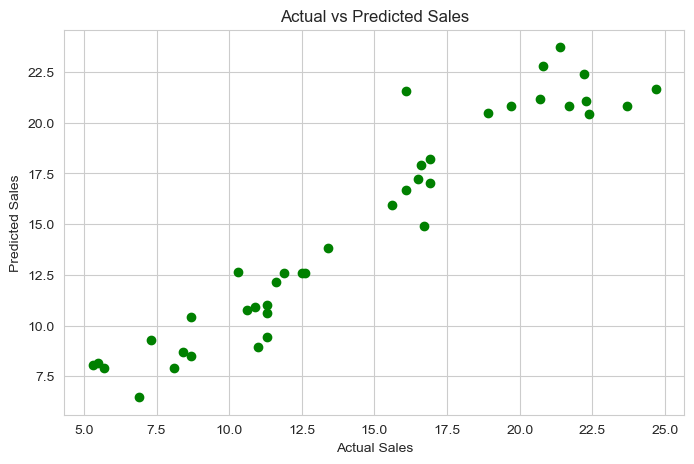

In [15]:
plt.figure(figsize=(8,5))

plt.scatter(y_test, y_pred, color='green')

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")

plt.title("Actual vs Predicted Sales")

plt.show()

Sample Prediction

In [16]:
sample_data = pd.DataFrame({
    'TV':[230.1],
    'Radio':[37.8],
    'Newspaper':[69.2]
})

prediction = model.predict(sample_data)

print("\nPredicted Sales :", prediction[0])


Predicted Sales : 21.372540280396883
